In [1]:
import pyspark
from pyspark.sql import SparkSession

In [2]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("test") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

In [3]:
df_data = spark.read \
    .option("recursiveFileLookup", "true") \
    .parquet("../data/aggregation/1979-2025")

In [4]:
df_data.show()

+---------------+--------------+---------------+---------------+-----------------+-------------+------------------+----------+-----------+----+---------+-----------+----------------+------------------+-----------------------+-------------------+
|collision_index|casualty_class|sex_of_casualty|age_of_casualty|casualty_severity|casualty_type|collision_severity|      date|day_of_week|time|road_type|speed_limit|light_conditions|weather_conditions|road_surface_conditions|urban_or_rural_area|
+---------------+--------------+---------------+---------------+-----------------+-------------+------------------+----------+-----------+----+---------+-----------+----------------+------------------+-----------------------+-------------------+
|  197901A1DAK71|             1|              1|             24|                3|          109|                 3|1979-01-01|          2|   3|        9|         30|               4|                 8|                      3|                 -1|
|  197901A1DAK71

In [5]:
# Total record after join
df_data.count()

12035241

In [6]:
df_data.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- casualty_class: integer (nullable = true)
 |-- sex_of_casualty: integer (nullable = true)
 |-- age_of_casualty: integer (nullable = true)
 |-- casualty_severity: integer (nullable = true)
 |-- casualty_type: integer (nullable = true)
 |-- collision_severity: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- time: integer (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable = true)
 |-- light_conditions: integer (nullable = true)
 |-- weather_conditions: integer (nullable = true)
 |-- road_surface_conditions: integer (nullable = true)
 |-- urban_or_rural_area: integer (nullable = true)



In [7]:
cat_col = [
    "casualty_class",
    "sex_of_casualty",
    "casualty_type",
    "road_type",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area"
]

time_col = [
    "date",
    "day_of_week",
    "time"
]

numeric_col = [
    "age_of_casualty",
    "speed_limit"
]

lable_col = [
    "casualty_class"
]

In [15]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def check_missing_val(df):
    check_list = []
    
    for col_name, dtype in df.dtypes:
        condition = F.col(col_name).isNull()
        
        if dtype in ['double', 'float']:
            condition = condition | F.isnan(F.col(col_name))
    
        check_list.append(F.count(F.when(condition, col_name)).alias(col_name))
        
    df_missing = df.select(*check_list).toPandas()
    df_missing = df_missing.T.reset_index()
    df_missing.columns = ['Features', 'Missing values']

    df_missing = df_missing[df_missing['Missing values'] > 0].sort_values(by='Missing values', ascending=False)

    return df_missing

check_missing_val(df_data)

,Features,Missing values
11,speed_limit,47
7,date,10
9,time,10


C:\Users\Admin\AppData\Local\Temp\ipykernel_19960\1042458896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


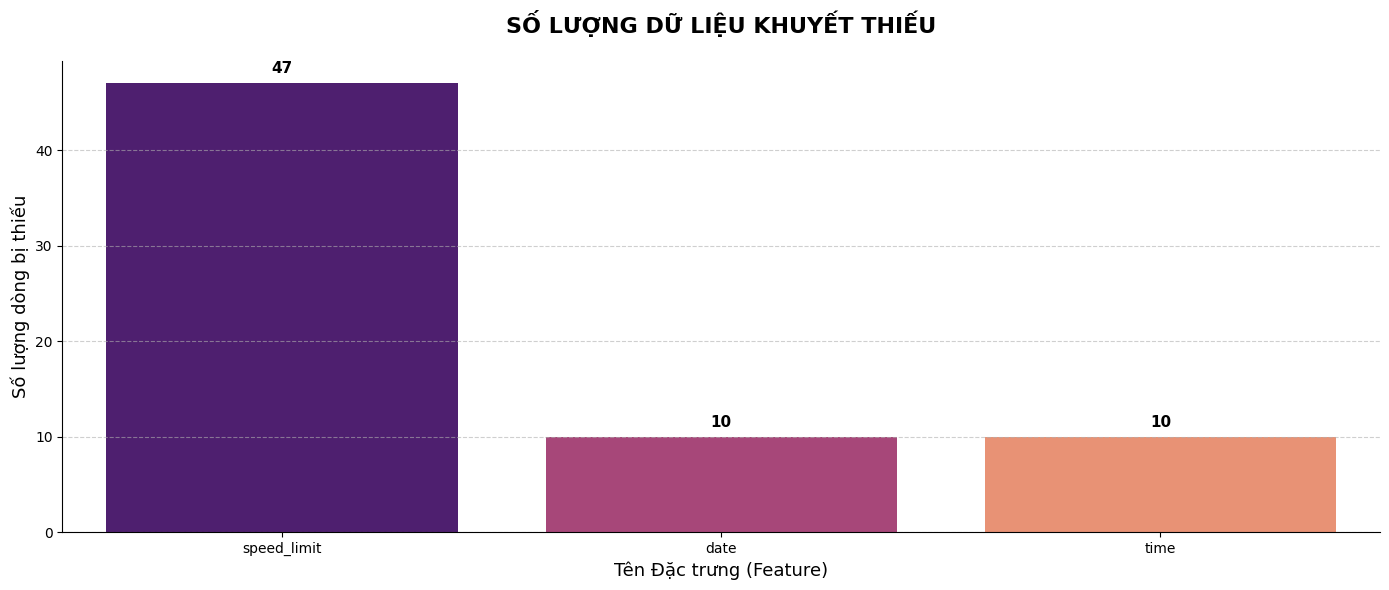

In [ ]:
df_missing_data = check_missing_val(df_data)

if df_missing_data.empty:
    print("Dataset has no empty value!")
else:
    plt.figure(figsize=(14,6))
    ax = sns.barplot(
        data=df_missing_data, 
        x='Features', 
        y='Missing values', 
        palette='magma'
    )
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color='black', 
                    xytext=(0, 5), textcoords='offset points')
    plt.title("SỐ LƯỢNG DỮ LIỆU KHUYẾT THIẾU", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Tên Đặc trưng (Feature)", fontsize=13)
    plt.ylabel("Số lượng dòng bị thiếu", fontsize=13)

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    sns.despine()

    plt.tight_layout()
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19960\3601666536.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


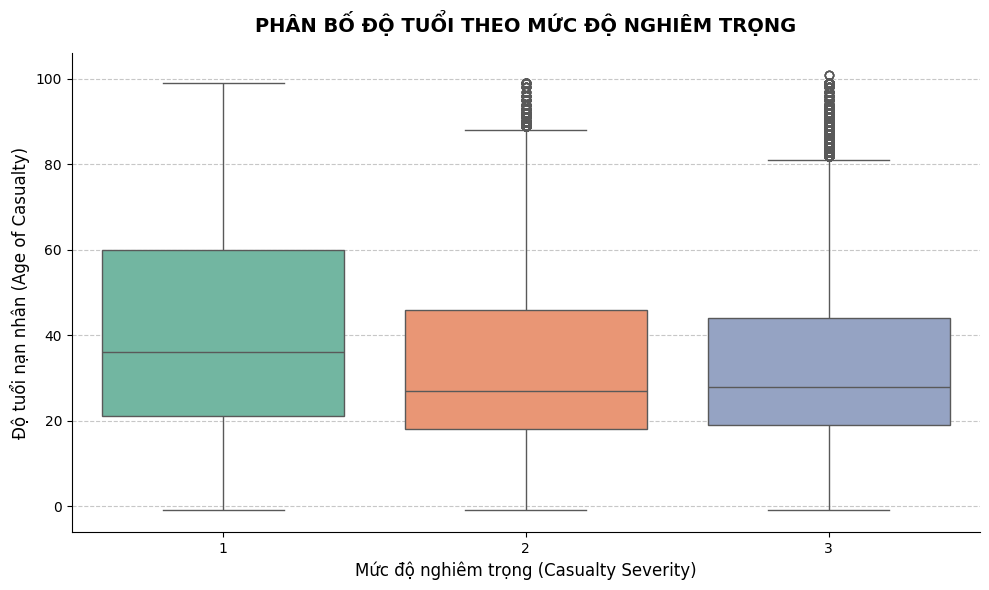

In [29]:
ratio = {1.0: 0.1, 2.0: 0.1, 3.0: 0.1}
df_stratified_sample = df_data.sampleBy('casualty_severity', fractions=ratio, seed=42)
df_box = df_stratified_sample.select('casualty_severity', 'age_of_casualty').toPandas()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_box, 
    x='casualty_severity', 
    y='age_of_casualty', 
    palette='Set2'
)

plt.title("PHÂN BỐ ĐỘ TUỔI THEO MỨC ĐỘ NGHIÊM TRỌNG", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mức độ nghiêm trọng (Casualty Severity)", fontsize=12)
plt.ylabel("Độ tuổi nạn nhân (Age of Casualty)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19960\1021639628.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


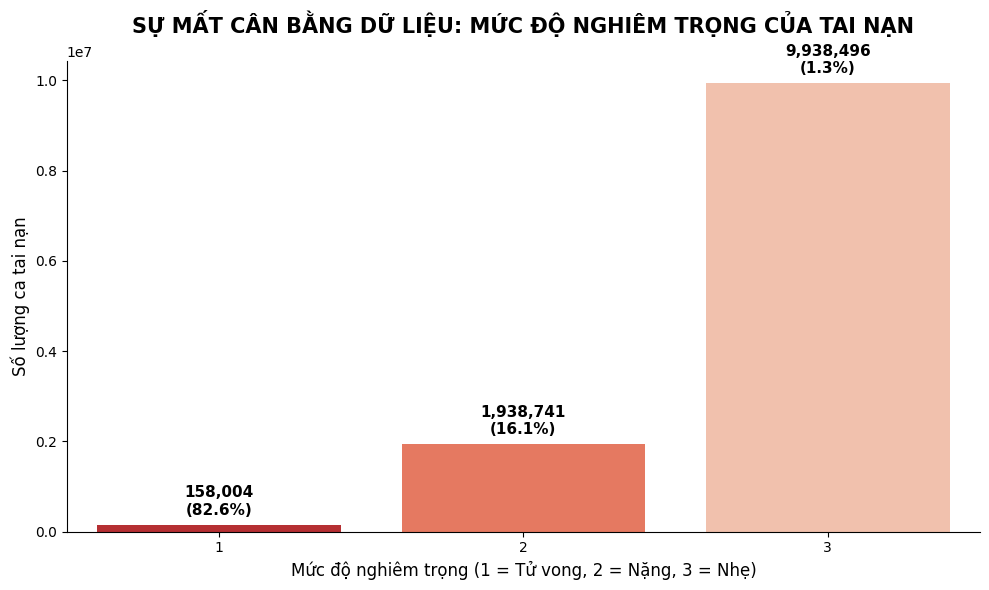

In [ ]:
import pyspark.sql.functions as F

df_imbalance = df_data.groupBy('casualty_severity').count().toPandas()
df_imbalance = df_imbalance.sort_values(by='count', ascending=False)

total_records = df_imbalance['count'].sum()
df_imbalance['percent'] = (df_imbalance['count'] / total_records) * 100
df_imbalance.head()

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=df_imbalance, 
    x='casualty_severity', 
    y='count', 
    palette='Reds_r'
)

for index, p in enumerate(ax.patches):
    count_val = int(p.get_height())
    percent_val = df_imbalance.iloc[index]['percent']
    
    ax.annotate(f'{count_val:,}\n({percent_val:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black', 
                xytext=(0, 5), textcoords='offset points')
    
plt.title("SỰ MẤT CÂN BẰNG DỮ LIỆU: MỨC ĐỘ NGHIÊM TRỌNG CỦA TAI NẠN", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Mức độ nghiêm trọng (1 = Tử vong, 2 = Nặng, 3 = Nhẹ)", fontsize=12)
plt.ylabel("Số lượng ca tai nạn", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

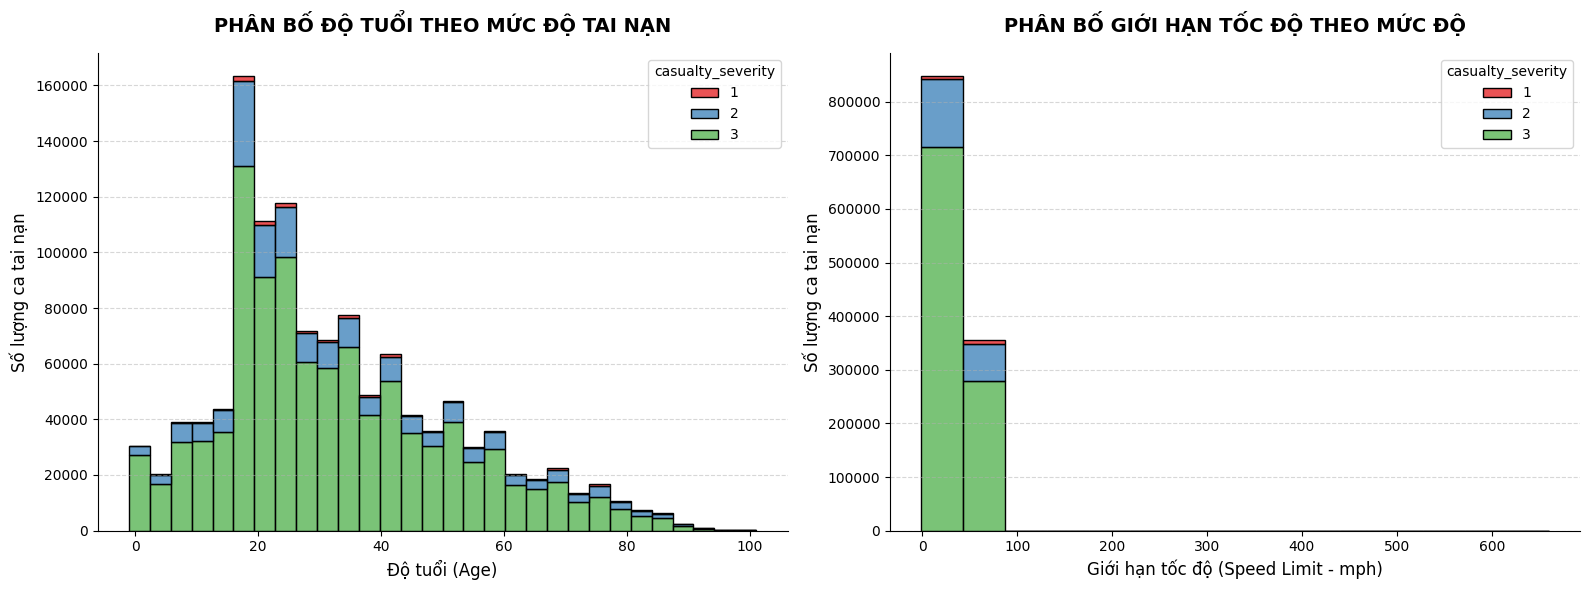

In [32]:
ratio = {1.0: 0.05, 2.0: 0.05, 3.0: 0.05}
df_hist = df_stratified_sample.select('casualty_severity', 'age_of_casualty', 'speed_limit').toPandas()
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.histplot(
    data=df_hist, 
    x='age_of_casualty', 
    hue='casualty_severity',
    multiple="stack",
    bins=30,
    palette='Set1',
    ax=axes[0]
)
axes[0].set_title("PHÂN BỐ ĐỘ TUỔI THEO MỨC ĐỘ TAI NẠN", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Độ tuổi (Age)", fontsize=12)
axes[0].set_ylabel("Số lượng ca tai nạn", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.histplot(
    data=df_hist, 
    x='speed_limit', 
    hue='casualty_severity', 
    multiple="stack", 
    bins=15, 
    palette='Set1',
    ax=axes[1]
)
axes[1].set_title("PHÂN BỐ GIỚI HẠN TỐC ĐỘ THEO MỨC ĐỘ", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Giới hạn tốc độ (Speed Limit - mph)", fontsize=12)
axes[1].set_ylabel("Số lượng ca tai nạn", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()